In [6]:
import os
import re
import numpy as np
import pandas as pd
import sympy as sp

Settings

In [7]:
CSV_PATH = "FeynmanEquations.csv"
OUTPUT_DIR = "data"

SELECTED_EQUATIONS = [
    "I.6.2",     # easy, 2 variables
    "I.14.3",    # easy, 3 variables
    "I.18.4",    # medium, 4 variables
    "I.29.16",   # medium, 4 variables, cos/sqrt
    "I.9.18",    # hard, 9 variables
]

N_TRAIN = 10_000
N_VAL = 2_000
N_TEST = 2_000

NOISE_LEVELS = [0.0, 0.01, 0.05, 0.1]

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

Load and inspect the CSV

In [8]:
equations_df = pd.read_csv(CSV_PATH)

equations_df.head()

equations_df[equations_df["Filename"].isin(SELECTED_EQUATIONS)][
    ["Filename", "Formula", "# variables"]
]

,Filename,Formula,# variables
1,I.6.2,exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma),2.0
4,I.9.18,G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2),9.0
14,I.14.3,m*g*z,3.0
20,I.18.4,(m1*r1+m2*r2)/(m1+m2),4.0
28,I.29.16,sqrt(x1**2+x2**2-2*x1*x2*cos(theta1-theta2)),4.0


Helper Functions

In [9]:
def safe_filename(name):
    """
    Convert equation names like 'I.6.2' into folder-safe names like 'I_6_2'.
    """
    return re.sub(r"[^A-Za-z0-9]+", "_", name).strip("_")


def get_variables_and_ranges(row):
    """
    Extract variable names and their low/high ranges from the CSV row.
    """
    n_vars = int(row["# variables"])

    var_names = []
    lows = []
    highs = []

    for i in range(1, n_vars + 1):
        var_names.append(str(row[f"v{i}_name"]))
        lows.append(float(row[f"v{i}_low"]))
        highs.append(float(row[f"v{i}_high"]))

    return var_names, np.array(lows), np.array(highs)


def build_equation_function(formula, var_names):
    """
    Convert a symbolic formula string into a NumPy function.
    """
    symbols = sp.symbols(var_names)

    local_dict = {
        "pi": sp.pi,
        "sqrt": sp.sqrt,
        "sin": sp.sin,
        "cos": sp.cos,
        "tan": sp.tan,
        "exp": sp.exp,
        "log": sp.log,
    }

    for name, symbol in zip(var_names, symbols):
        local_dict[name] = symbol

    expression = sp.sympify(formula, locals=local_dict)
    numerical_func = sp.lambdify(symbols, expression, modules=["numpy"])

    def f(X):
        inputs = [X[:, i] for i in range(X.shape[1])]
        y = numerical_func(*inputs)
        y = np.asarray(y, dtype=np.float64)

        if y.shape == ():
            y = np.full(X.shape[0], float(y))

        return y.reshape(-1)

    return f


def sample_data(equation_func, lows, highs, n_samples, rng):
    """
    Sample input variables uniformly from their allowed domains.
    Then calculate y using the true equation.
    """
    n_vars = len(lows)
    X = rng.uniform(low=lows, high=highs, size=(n_samples, n_vars))
    y = equation_func(X)

    valid_mask = np.isfinite(y)
    X = X[valid_mask]
    y = y[valid_mask]

    return X, y


def generate_exact_split(equation_func, lows, highs, n_required, rng):
    """
    Keep sampling until exactly n_required valid rows are generated.
    """
    X_parts = []
    y_parts = []

    while sum(len(y) for y in y_parts) < n_required:
        n_remaining = n_required - sum(len(y) for y in y_parts)
        n_attempt = int(n_remaining * 1.2) + 20

        X_new, y_new = sample_data(equation_func, lows, highs, n_attempt, rng)

        X_parts.append(X_new)
        y_parts.append(y_new)

    X = np.vstack(X_parts)[:n_required]
    y = np.concatenate(y_parts)[:n_required]

    return X, y


def add_gaussian_noise(y, sigma, rng):
    """
    Add Gaussian noise to y.

    Noise is scaled by the standard deviation of y so that sigma behaves
    consistently across different equations.
    """
    if sigma == 0:
        return y.copy()

    y_std = np.std(y)

    if y_std == 0:
        y_std = 1.0

    noise = rng.normal(0, sigma * y_std, size=y.shape)

    return y + noise


def save_dataset(X, y, var_names, path):
    """
    Save X and y into a CSV file.
    """
    df = pd.DataFrame(X, columns=var_names)
    df["y"] = y
    df.to_csv(path, index=False)

Generate the datasets

In [10]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

metadata_rows = []

for equation_name in SELECTED_EQUATIONS:
    print(f"\nGenerating data for {equation_name}")

    row = equations_df[equations_df["Filename"] == equation_name].iloc[0]

    formula = row["Formula"]
    n_vars = int(row["# variables"])
    var_names, lows, highs = get_variables_and_ranges(row)
    equation_func = build_equation_function(formula, var_names)

    clean_name = safe_filename(equation_name)
    equation_dir = os.path.join(OUTPUT_DIR, clean_name)
    os.makedirs(equation_dir, exist_ok=True)

    # Generate clean datasets
    X_train, y_train_clean = generate_exact_split(
        equation_func, lows, highs, N_TRAIN, rng
    )

    X_val, y_val = generate_exact_split(
        equation_func, lows, highs, N_VAL, rng
    )

    X_test, y_test = generate_exact_split(
        equation_func, lows, highs, N_TEST, rng
    )

    # Save clean train, validation, and test sets
    save_dataset(
        X_train,
        y_train_clean,
        var_names,
        os.path.join(equation_dir, "train_clean.csv")
    )

    save_dataset(
        X_val,
        y_val,
        var_names,
        os.path.join(equation_dir, "val_clean.csv")
    )

    save_dataset(
        X_test,
        y_test,
        var_names,
        os.path.join(equation_dir, "test_clean.csv")
    )

    # Save noisy training sets
    for sigma in NOISE_LEVELS:
        y_train_noisy = add_gaussian_noise(y_train_clean, sigma, rng)
        sigma_label = str(sigma).replace(".", "p")

        save_dataset(
            X_train,
            y_train_noisy,
            var_names,
            os.path.join(equation_dir, f"train_noise_{sigma_label}.csv")
        )

    metadata_rows.append({
        "equation": equation_name,
        "safe_name": clean_name,
        "formula": formula,
        "difficulty": "easy" if n_vars <= 3 else "medium" if n_vars <= 5 else "hard",
        "n_variables": n_vars,
        "variables": ", ".join(var_names),
        "lows": ", ".join(map(str, lows)),
        "highs": ", ".join(map(str, highs)),
        "n_train": N_TRAIN,
        "n_val": N_VAL,
        "n_test": N_TEST,
    })

    print("Formula:", formula)
    print("Variables:", var_names)
    print("Saved to:", equation_dir)

metadata_df = pd.DataFrame(metadata_rows)
metadata_df.to_csv(os.path.join(OUTPUT_DIR, "selected_equations_metadata.csv"), index=False)

print("\nDone. Data generated.")


Generating data for I.6.2
Formula: exp(-(theta/sigma)**2/2)/(sqrt(2*pi)*sigma)
Variables: ['sigma', 'theta']
Saved to: data/I_6_2

Generating data for I.14.3
Formula: m*g*z
Variables: ['m', 'g', 'z']
Saved to: data/I_14_3

Generating data for I.18.4
Formula: (m1*r1+m2*r2)/(m1+m2)
Variables: ['m1', 'm2', 'r1', 'r2']
Saved to: data/I_18_4

Generating data for I.29.16
Formula: sqrt(x1**2+x2**2-2*x1*x2*cos(theta1-theta2))
Variables: ['x1', 'x2', 'theta1', 'theta2']
Saved to: data/I_29_16

Generating data for I.9.18
Formula: G*m1*m2/((x2-x1)**2+(y2-y1)**2+(z2-z1)**2)
Variables: ['m1', 'm2', 'G', 'x1', 'x2', 'y1', 'y2', 'z1', 'z2']
Saved to: data/I_9_18

Done. Data generated.


Checking

In [11]:
metadata_df
for equation_name in SELECTED_EQUATIONS:
    clean_name = safe_filename(equation_name)
    path = os.path.join(OUTPUT_DIR, clean_name, "train_clean.csv")

    df = pd.read_csv(path)

    print("\n", equation_name)
    print("Path:", path)
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))
    print("Any NaN:", df.isna().any().any())
    display(df.head())


 I.6.2
Path: data/I_6_2/train_clean.csv
Shape: (10000, 3)
Columns: ['sigma', 'theta', 'y']
Any NaN: False


,sigma,theta,y
0,2.547912,1.877757,0.119340
1,2.717196,2.394736,0.099569
2,1.188355,2.951245,0.015370
3,2.522279,2.572129,0.094038
4,1.256227,1.900772,0.101089



 I.14.3
Path: data/I_14_3/train_clean.csv
Shape: (10000, 4)
Columns: ['m', 'g', 'z', 'y']
Any NaN: False


,m,g,z,y
0,1.195260,2.784330,4.441755,14.782149
1,4.154220,4.824978,3.990002,79.975686
2,1.645335,1.806080,2.382413,7.079594
3,1.460507,3.773327,2.433501,13.410955
4,1.785074,1.943468,4.763276,16.524921



 I.18.4
Path: data/I_18_4/train_clean.csv
Shape: (10000, 5)
Columns: ['m1', 'm2', 'r1', 'r2', 'y']
Any NaN: False


,m1,m2,r1,r2,y
0,2.785658,1.635411,4.619519,3.909892,4.357019
1,3.976569,3.674515,4.564868,3.786999,4.191288
2,3.865742,3.633647,4.717070,3.842123,4.293136
3,3.705220,2.559248,1.897607,2.634890,2.198812
4,1.520505,1.987201,4.569035,3.811347,4.139787



 I.29.16
Path: data/I_29_16/train_clean.csv
Shape: (10000, 5)
Columns: ['x1', 'x2', 'theta1', 'theta2', 'y']
Any NaN: False


,x1,x2,theta1,theta2,y
0,1.130697,2.838656,4.640969,4.109228,1.950249
1,4.813305,4.771464,3.030432,2.450427,2.741099
2,2.627627,3.891320,4.045374,3.372938,2.459415
3,3.356003,1.136257,1.118652,3.903355,4.438449
4,2.362951,2.372324,4.827534,4.436905,0.919044



 I.9.18
Path: data/I_9_18/train_clean.csv
Shape: (10000, 10)
Columns: ['m1', 'm2', 'G', 'x1', 'x2', 'y1', 'y2', 'z1', 'z2', 'y']
Any NaN: False


,m1,m2,G,x1,x2,y1,y2,z1,z2,y
0,1.015414,1.628354,1.512522,3.484406,1.063328,3.029110,1.707457,3.017213,1.128720,0.223797
1,1.456610,1.245159,1.198940,3.447530,1.999327,3.238715,1.093243,3.508385,1.034482,0.169613
2,1.975249,1.380403,1.633510,3.295111,1.315205,3.803721,1.067709,3.892158,1.061322,0.229358
3,1.016872,1.518907,1.971586,3.024064,1.953486,3.604533,1.114613,3.169901,1.518095,0.302272
4,1.667453,1.504155,1.214455,3.930714,1.736380,3.231858,1.399167,3.000203,1.240766,0.270286


Plot

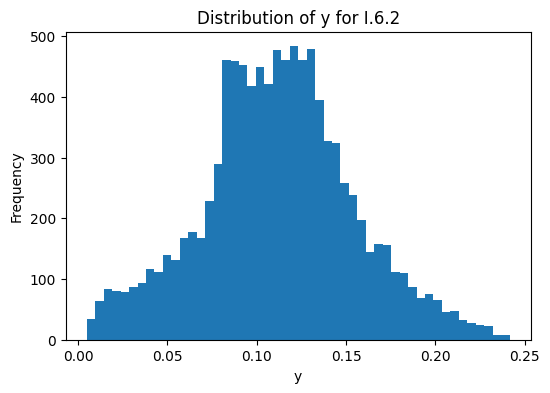

In [12]:
import matplotlib.pyplot as plt

equation_name = "I.6.2"
clean_name = safe_filename(equation_name)

df = pd.read_csv(os.path.join(OUTPUT_DIR, clean_name, "train_clean.csv"))

plt.figure(figsize=(6, 4))
plt.hist(df["y"], bins=50)
plt.xlabel("y")
plt.ylabel("Frequency")
plt.title(f"Distribution of y for {equation_name}")
plt.show()

More checking

In [13]:
df = pd.read_csv("data/I_6_2/train_clean.csv")

print(df.describe())
print("Any NaN:", df.isna().any().any())
print("Any infinite:", np.isinf(df.to_numpy()).any())
print("Min y:", df["y"].min())
print("Max y:", df["y"].max())

              sigma         theta             y
count  10000.000000  10000.000000  10000.000000
mean       2.000971      1.999144      0.111849
std        0.576792      0.577594      0.042642
min        1.000218      1.000026      0.004915
25%        1.500126      1.492472      0.085264
50%        2.008430      2.001383      0.112130
75%        2.494380      2.500270      0.137863
max        2.999895      2.999954      0.241473
Any NaN: False
Any infinite: False
Min y: 0.00491490018956
Max y: 0.2414734343954771


final check

In [14]:
import os
import pandas as pd
import numpy as np

summary = []

for equation_name in SELECTED_EQUATIONS:
    clean_name = safe_filename(equation_name)
    equation_dir = os.path.join(OUTPUT_DIR, clean_name)

    for file in os.listdir(equation_dir):
        if file.endswith(".csv"):
            path = os.path.join(equation_dir, file)
            df = pd.read_csv(path)

            summary.append({
                "equation": equation_name,
                "file": file,
                "rows": df.shape[0],
                "columns": df.shape[1],
                "has_nan": df.isna().any().any(),
                "has_inf": np.isinf(df.to_numpy()).any(),
                "y_min": df["y"].min(),
                "y_max": df["y"].max(),
                "y_mean": df["y"].mean(),
                "y_std": df["y"].std()
            })

summary_df = pd.DataFrame(summary)
summary_df

,equation,file,rows,columns,has_nan,has_inf,y_min,y_max,y_mean,y_std
0,I.6.2,train_clean.csv,10000,3,False,False,0.004915,0.241473,0.111849,0.042642
1,I.6.2,train_noise_0p0.csv,10000,3,False,False,0.004915,0.241473,0.111849,0.042642
2,I.6.2,train_noise_0p1.csv,10000,3,False,False,-0.001559,0.247154,0.111800,0.042882
3,I.6.2,test_clean.csv,2000,3,False,False,0.005463,0.240160,0.112566,0.042713
4,I.6.2,val_clean.csv,2000,3,False,False,0.006849,0.231526,0.113058,0.043271
5,I.6.2,train_noise_0p01.csv,10000,3,False,False,0.004700,0.241928,0.111841,0.042638
6,I.6.2,train_noise_0p05.csv,10000,3,False,False,0.004779,0.240804,0.111836,0.042676
7,I.14.3,train_clean.csv,10000,4,False,False,1.355958,119.728071,27.101420,19.289428
8,I.14.3,train_noise_0p0.csv,10000,4,False,False,1.355958,119.728071,27.101420,19.289428
9,I.14.3,train_noise_0p1.csv,10000,4,False,False,-2.083430,121.953266,27.122210,19.376466


In [16]:
%%writefile README.md
# Feynman Equation Dataset Generation

This folder contains the generated datasets for the KAN/KAN 2.0 symbolic regression project.

## Purpose

The project compares MLP, KAN, and KAN 2.0 models on selected equations from the Feynman symbolic regression dataset.

For each selected equation, input variables were sampled uniformly from the equation's specified input domain. The target value `y` was calculated using the known ground-truth equation.

Each equation has:

- 10,000 training samples
- 2,000 validation samples
- 2,000 test samples
- clean training data
- noisy training data for noise robustness experiments

Noise was added only to the training target values. Validation and test sets remain clean.

## Selected Equations

| Difficulty | Equation ID | Formula |
|---|---|---|
| Easy | I.6.2 | exp(-(theta/sigma)^2/2)/(sqrt(2*pi)*sigma) |
| Easy | I.14.3 | m*g*z |
| Medium | I.18.4 | (m1*r1+m2*r2)/(m1+m2) |
| Medium | I.29.16 | sqrt(x1^2+x2^2-2*x1*x2*cos(theta1-theta2)) |
| Hard | I.9.18 | G*m1*m2/((x2-x1)^2+(y2-y1)^2+(z2-z1)^2) |

## Folder Structure

```text
data/
├── selected_equations_metadata.csv
├── data_generation_summary.csv
├── I_6_2/
│   ├── train_clean.csv
│   ├── train_noise_0p0.csv
│   ├── train_noise_0p01.csv
│   ├── train_noise_0p05.csv
│   ├── train_noise_0p1.csv
│   ├── val_clean.csv
│   └── test_clean.csv
├── I_14_3/
├── I_18_4/
├── I_29_16/
└── I_9_18/

Writing README.md
